In [8]:
import dill 
import torch 
import torch.nn as nn
import numpy as np
from four_room.shortest_path import find_all_action_values
from four_room.env import FourRoomsEnv
from four_room.wrappers import gym_wrapper
import numpy as np
import imageio
import gymnasium as gym
from four_room.utils import obs_to_state
from four_room.arch import CNN
from tqdm import tqdm
import matplotlib.pyplot as plt
import random
from hashlib import sha1

from regression.experiment import Experiment


import warnings
warnings.filterwarnings(action='once')
device = 'cuda' if torch.cuda.is_available() else 'cpu'
gym.register('MiniGrid-FourRooms-v1', FourRoomsEnv)
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


c:\Users\garga\Documents\Uni\four_room\venv\Lib\site-packages\gymnasium\envs\registration.py:694: UserWarning: WARN: Overriding environment MiniGrid-FourRooms-v1 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")


RUNNING EXPERIMENT comparison_explorego_star1 ON DEVICE: cuda
=============Seed 0===============

For dataset: ExploreGo 25K || Step: 200000 / 200000 | Loss: 0.000 | Val Rewards: 0.425 | Hours left: 0.0ours left: 0.0

=============Seed 1===============

For dataset: ExploreGo 25K || Step: 200000 / 200000 | Loss: 0.000 | Val Rewards: 0.375 | Hours left: 0.0ours left: 0.0

=============Seed 2===============

For dataset: ExploreGo 25K || Step: 200000 / 200000 | Loss: 0.000 | Val Rewards: 0.250 | Hours left: 0.0ours left: 0.0

=============Seed 3===============

For dataset: ExploreGo 25K || Step: 200000 / 200000 | Loss: 0.000 | Val Rewards: 0.325 | Hours left: 0.0ours left: 0.0

Dataset: ExploreGo* 25K | Test results: 0.5425
Dataset: Avoid 25K (Min Overlap 0.2) | Test results: 0.7512
Dataset: ExploreGo 25K | Test results: 0.4575


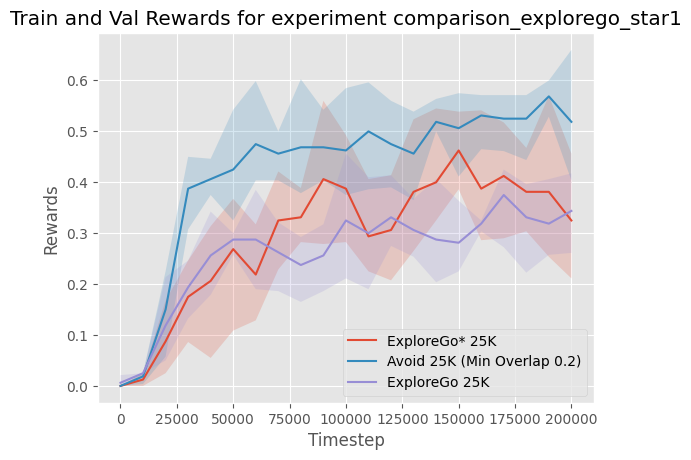

In [ ]:
with open(f'action_values/star_25k.pl', 'rb') as file:
    star = dill.load(file)
    
with open(f'action_values/explorego_25k.pl', 'rb') as file:
    explore = dill.load(file)
    
with open(f'action_values/avoid_25k_02.pl', 'rb') as file:
    avoid_02 = dill.load(file)
    
with open(f'action_values/avoid_25k_04.pl', 'rb') as file:
    avoid_04 = dill.load(file)

avoid_vs_explorego = Experiment(
    'comparison_explorego_star1', 
    seeds=[0, 1, 2, 3],
    timesteps=int(2e5), 
    val_freq=int(1e4),
    batch_size=64
)

avoid_vs_explorego.run_experiment([star, avoid_02, avoid_04,explore], 
                               ['ExploreGo* 25K', 'Avoid 25K (Min Overlap 0.2)', 'Avoid 25K (Min Overlap 0.4)', 'ExploreGo 25K'])


In [17]:
with open(f'action_values/star_50k.pl', 'rb') as file:
    star = dill.load(file)
    
with open(f'action_values/explorego_50k.pl', 'rb') as file:
    explore = dill.load(file)
    
with open(f'action_values/avoid_50k_02.pl', 'rb') as file:
    avoid_02 = dill.load(file)
    
with open(f'action_values/avoid_50k_04.pl', 'rb') as file:
    avoid_04 = dill.load(file)

avoid_vs_explorego = Experiment(
    'comparison_explorego_star2', 
    seeds=[0, 1, 2, 3],
    timesteps=int(2e5), 
    val_freq=int(1e4),
    batch_size=64
)

avoid_vs_explorego.run_experiment([star, avoid_02, avoid_04, explore], 
                               ['ExploreGo* 50K', 'Avoid 50K (Min Overlap 0.2)', 'Avoid 50K (Min Overlap 0.4)', 'ExploreGo 50K'])


RUNNING EXPERIMENT comparison_explorego_star2 ON DEVICE: cuda
=============Seed 0===============

Experiment stopped prematurely Step: 10000 / 200000 | Loss: 0.000 | Val Rewards: 0.025 | Hours left: 0.4


In [ ]:
with open(f'action_values/star_80k.pl', 'rb') as file:
    star = dill.load(file)
    
with open(f'action_values/explorego_80k.pl', 'rb') as file:
    explore = dill.load(file)
    
with open(f'action_values/avoid_80k_02.pl', 'rb') as file:
    avoid_02 = dill.load(file)
    
with open(f'action_values/avoid_80k_04.pl', 'rb') as file:
    avoid_04 = dill.load(file)
    
    
avoid_vs_explorego = Experiment(
    'comparison_explorego_star3', 
    seeds=[0, 1, 2, 3],
    timesteps=int(2e5), 
    val_freq=int(1e4),
    batch_size=64
)

avoid_vs_explorego.run_experiment([star, avoid_02, avoid_04, explore], 
                               ['ExploreGo* 80K', 'Avoid 80K (Min Overlap 0.2)', 'Avoid 80K (Min Overlap 0.4)', 'ExploreGo 80K'])


RUNNING EXPERIMENT comparison_explorego_star3 ON DEVICE: cuda
=============Seed 0===============

Experiment stopped prematurely Step: 0 / 200000 | Loss: 0.786 | Val Rewards: 0.000 | Hours left: 0.1
